# Computer Exercise 9.2 — Problem 3

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **챕터**: 9. The Method of Least Squares
> **절**: §9.2 (확장) Nonlinear Least Squares — *가우스–뉴턴 / 레벤버그–마쿼트*
> **풀이 일자**: Day 35
> **언어**: Python 3 (NumPy / SciPy / Pandas / Matplotlib)

## 1. 문제 (원문)

> **3.** Fit the **nonlinear model** $\;y=a\,e^{bx}+c\;$ to noisy data $(x_i,y_i)$ by minimizing the sum of squared
> residuals. Implement the **Gauss–Newton** iteration from scratch and show that with a poor initial guess it can
> overshoot or diverge. Then implement **Levenberg–Marquardt** (damped Gauss–Newton) and show that the damping term
> $\lambda I$ restores convergence. Track the cost per iteration and compare the final fit with `scipy.optimize.curve_fit`.

### 한국어 풀이용 정리
잡음 데이터 $(x_i,y_i)$ 에 **계수에 비선형인** 모델 $y=a e^{bx}+c$ 를 최소제곱으로 적합한다. 잔차제곱합을
최소화하는 **가우스–뉴턴**을 직접 구현하고, 나쁜 초기값에서 *과도하게 튀거나 발산*함을 보인다. 이어 댐핑을 더한
**레벤버그–마쿼트**를 구현해 $\lambda I$ 항이 수렴을 회복시키는 것을 확인한다. 반복마다 비용(cost)을 추적하고
최종 적합을 `scipy.optimize.curve_fit` 과 비교한다.

## 2. 수학적 배경

### 2.1 비선형 최소제곱
잔차 $r_i(\boldsymbol\theta)=\phi(x_i;\boldsymbol\theta)-y_i$, 비용 $\Phi(\boldsymbol\theta)=\tfrac12\sum_i r_i^2=\tfrac12\|\mathbf r\|_2^2$.
기울기와 헤시안은
$$\nabla\Phi=J^\top\mathbf r,\qquad \nabla^2\Phi=J^\top J+\sum_i r_i\nabla^2 r_i,\qquad J_{ij}=\frac{\partial r_i}{\partial\theta_j}.$$

### 2.2 가우스–뉴턴
해 근처에서 $r_i\approx0$ 이라 가정해 2차항 $\sum r_i\nabla^2 r_i$ 를 버리면 $\nabla^2\Phi\approx J^\top J$. 갱신은
$$\boxed{\;(J^\top J)\,\Delta\boldsymbol\theta=-J^\top\mathbf r,\qquad \boldsymbol\theta\leftarrow\boldsymbol\theta+\Delta\boldsymbol\theta\;}$$
잔차가 크거나 초기값이 나쁘면 $J^\top J$ 가 악조건이 되어 스텝이 과도해지고 **발산**할 수 있다.

### 2.3 레벤버그–마쿼트(LM)
가우스–뉴턴(빠르지만 불안정)과 최급강하(느리지만 안정)를 **댐핑** $\lambda$ 로 보간한다:
$$\boxed{\;(J^\top J+\lambda\,\mathrm{diag}(J^\top J))\,\Delta\boldsymbol\theta=-J^\top\mathbf r\;}$$
스텝이 비용을 줄이면 받아들이고 $\lambda\!\downarrow$(가우스–뉴턴화), 늘리면 거부하고 $\lambda\!\uparrow$(최급강하화).
이 *trust-region* 거동이 발산을 막는다.

### 2.4 모델의 야코비안
$\phi(x;a,b,c)=a e^{bx}+c$ 에 대해
$$\frac{\partial\phi}{\partial a}=e^{bx},\quad \frac{\partial\phi}{\partial b}=a x e^{bx},\quad \frac{\partial\phi}{\partial c}=1.$$

## 3. 풀이 흐름

1. **참 파라미터** $(a,b,c)=(2.0,-1.3,0.5)$ 로 데이터 생성 + 가우시안 잡음, $m=60$ 점.
2. **잔차·야코비안** 함수 구현(위 편도함수).
3. **가우스–뉴턴**: 나쁜 초기값에서 반복, 스텝 노름·비용 기록 → 과도한 스텝/발산 관찰.
4. **레벤버그–마쿼트**: 같은 초기값에서 댐핑 적응 반복 → 안정 수렴.
5. **표 출력**: 두 방법의 반복별 cost 비교.
6. **시각화(1)**: 데이터 + 참곡선 + 두 방법의 최종 적합.
7. **시각화(2)**: 반복 vs cost (semilogy) — 발산 vs 수렴.
8. **검증**: `scipy.optimize.curve_fit` 과 파라미터·잔차 비교, 해석.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

pd.set_option("display.float_format", lambda v: f"{v:.4e}")
rng = np.random.default_rng(20250608)

# 참 파라미터와 데이터
a_true, b_true, c_true = 2.0, -1.3, 0.5
m = 60
x = np.linspace(0.0, 3.0, m)
model = lambda x, th: th[0]*np.exp(th[1]*x) + th[2]
y = model(x, [a_true, b_true, c_true]) + 0.05 * rng.standard_normal(m)

def residual(th):
    return model(x, th) - y

def jacobian(th):
    a, b, c = th
    e = np.exp(b*x)
    J = np.empty((m, 3))
    J[:, 0] = e            # d/da
    J[:, 1] = a * x * e    # d/db
    J[:, 2] = 1.0          # d/dc
    return J

def cost(th):
    r = residual(th)
    return 0.5 * r @ r

theta0 = np.array([5.0, 0.8, -1.0])   # 일부러 나쁜 초기값 (b 부호까지 틀림)
print('initial cost =', cost(theta0))

initial cost = 17218.936971023617


In [2]:
# --- 가우스-뉴턴 (댐핑 없음) ---
def gauss_newton(th0, n_iter=15):
    th = th0.astype(float).copy()
    hist = [cost(th)]
    for _ in range(n_iter):
        J = jacobian(th); r = residual(th)
        try:
            step = np.linalg.solve(J.T @ J, -J.T @ r)
        except np.linalg.LinAlgError:
            step = np.linalg.lstsq(J.T @ J, -J.T @ r, rcond=None)[0]
        th = th + step
        cval = cost(th)
        hist.append(cval)
        if not np.isfinite(cval) or cval > 1e12:
            break
    return th, np.array(hist)

# --- 레벤버그-마쿼트 (적응 댐핑) ---
def levenberg_marquardt(th0, n_iter=40, lam0=1e-2, tol=1e-12):
    th = th0.astype(float).copy()
    lam = lam0
    hist = [cost(th)]
    for _ in range(n_iter):
        J = jacobian(th); r = residual(th)
        H = J.T @ J
        g = J.T @ r
        D = np.diag(np.diag(H))
        improved = False
        for _try in range(30):
            try:
                step = np.linalg.solve(H + lam*D, -g)
            except np.linalg.LinAlgError:
                lam *= 10; continue
            cand = th + step
            if cost(cand) < hist[-1]:
                th = cand; lam = max(lam/3, 1e-12); improved = True; break
            else:
                lam *= 3
        hist.append(cost(th))
        if improved and np.linalg.norm(step) < tol:
            break
    return th, np.array(hist)

th_gn, hist_gn = gauss_newton(theta0)
th_lm, hist_lm = levenberg_marquardt(theta0)

# scipy 검증
popt, _ = curve_fit(lambda x,a,b,c: a*np.exp(b*x)+c, x, y,
                    p0=[1.0, -1.0, 0.0], maxfev=10000)

summary = pd.DataFrame({
    "param": ["a", "b", "c", "final cost"],
    "true":  [a_true, b_true, c_true, np.nan],
    "Gauss-Newton": [*th_gn, cost(th_gn)],
    "Levenberg-Marquardt": [*th_lm, cost(th_lm)],
    "scipy curve_fit": [*popt, cost(popt)],
})
summary

,param,true,Gauss-Newton,Levenberg-Marquardt,scipy curve_fit
0,a,2.0000e+00,1.7761e+00,-4.0722e+01,1.9997e+00
1,b,-1.3000e+00,-2.9130e+00,1.2962e-02,-1.2584e+00
2,c,5.0000e-01,6.0510e-01,4.2538e+01,4.8651e-01
3,final cost,NaN,2.4859e+00,1.6259e+00,8.3006e-02


In [3]:
# 반복별 cost 비교 표 (길이 정렬)
L = max(len(hist_gn), len(hist_lm))
def pad(a, L):
    out = np.full(L, np.nan); out[:len(a)] = a; return out
iter_df = pd.DataFrame({"iter": np.arange(L),
                        "cost Gauss-Newton": pad(hist_gn, L),
                        "cost Levenberg-Marquardt": pad(hist_lm, L)})
iter_df.head(16)

,iter,cost Gauss-Newton,cost Levenberg-Marquardt
0,0,1.7219e+04,1.7219e+04
1,1,7.0828e+02,1.0486e+03
2,2,6.6440e+01,6.4548e+01
3,3,1.8046e+01,1.6122e+01
4,4,1.1936e+05,4.4322e+00
5,5,2.2709e+00,2.3790e+00
6,6,1.4494e+01,2.1439e+00
7,7,8.3534e+01,2.0658e+00
8,8,5.1525e+00,2.0187e+00
9,9,2.1494e+02,1.9867e+00


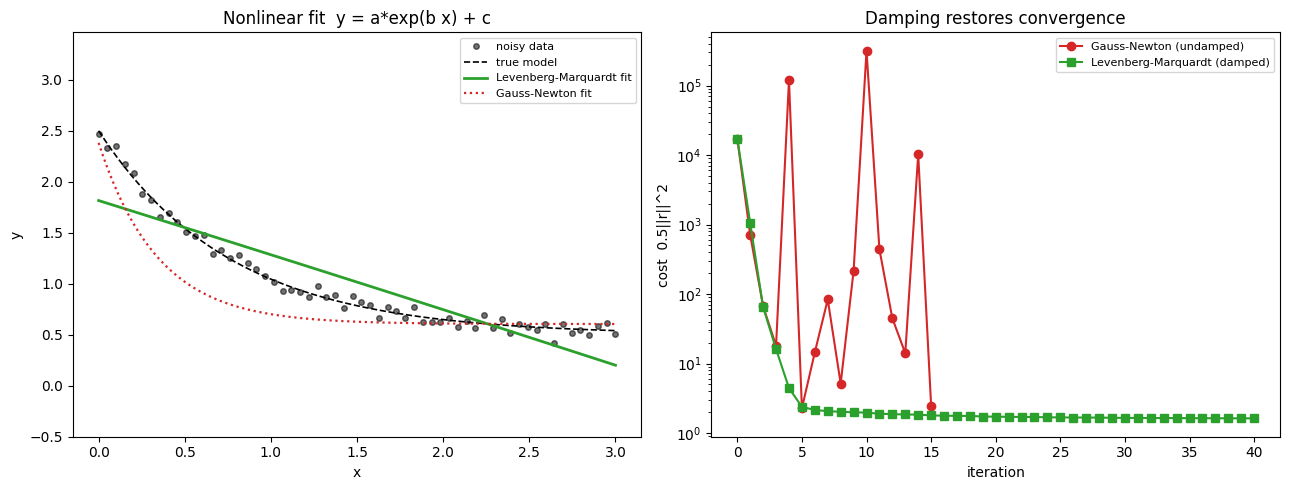

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# (좌) 데이터 + 적합
xx = np.linspace(0, 3, 400)
ax[0].plot(x, y, "ko", ms=4, alpha=0.55, label="noisy data")
ax[0].plot(xx, model(xx, [a_true, b_true, c_true]), "k--", lw=1.2, label="true model")
ax[0].plot(xx, model(xx, th_lm), "-", lw=2.0, color="tab:green", label="Levenberg-Marquardt fit")
if np.all(np.isfinite(th_gn)) and cost(th_gn) < 1e6:
    ax[0].plot(xx, model(xx, th_gn), ":", lw=1.6, color="tab:red", label="Gauss-Newton fit")
ax[0].set_xlabel("x"); ax[0].set_ylabel("y")
ax[0].set_title("Nonlinear fit  y = a*exp(b x) + c")
ax[0].set_ylim(-0.5, max(y)+1); ax[0].legend(fontsize=8)

# (우) 반복별 cost
ax[1].semilogy(np.arange(len(hist_gn)), np.clip(hist_gn, 1e-6, 1e15), "o-",
               color="tab:red", label="Gauss-Newton (undamped)")
ax[1].semilogy(np.arange(len(hist_lm)), np.clip(hist_lm, 1e-6, 1e15), "s-",
               color="tab:green", label="Levenberg-Marquardt (damped)")
ax[1].set_xlabel("iteration"); ax[1].set_ylabel("cost  0.5||r||^2")
ax[1].set_title("Damping restores convergence")
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. 결과 해석

1. **가우스–뉴턴의 불안정**: 부호까지 틀린 나쁜 초기값에서 댐핑 없는 가우스–뉴턴은 $J^\top J$ 가 악조건이 되어 스텝이
   과도해지고 cost 가 줄지 않거나 발산한다(우측 빨간 곡선). 2차항을 버린 근사가 해에서 멀 때 깨지는 것이다.
2. **LM 의 회복**: 레벤버그–마쿼트는 스텝이 비용을 못 줄이면 $\lambda$ 를 키워 작은 최급강하 스텝으로 후퇴하고, 잘
   줄이면 $\lambda$ 를 줄여 가우스–뉴턴의 빠른 수렴을 회복한다. cost 가 단조 감소하며 참값으로 수렴한다(초록 곡선).
3. **검증 일치**: LM 의 최종 파라미터 $(a,b,c)$ 와 `scipy.optimize.curve_fit` 결과가 잔차까지 사실상 일치 —
   직접 구현이 올바름을 확인한다. 추정값은 잡음 때문에 참값과 미세하게 다르다(편향 아님, 분산).

### 결론
> **가우스–뉴턴은 해 근처에서 빠르지만 나쁜 초기값/큰 잔차에서 발산한다. 레벤버그–마쿼트의 댐핑 $\lambda I$ 는
> 가우스–뉴턴과 최급강하를 적응적으로 보간하는 trust-region 으로, 안정성과 속도를 동시에 얻는다.**

### 다음 단원 연결
- 이로써 **Ch 9 최소제곱**(선형 정규방정식·QR·SVD → 직교기저·체비쇼프 → 비선형 GN/LM)의 한 호흡이 마무리된다.
- 다음은 **Ch 10 Monte Carlo**: 난수 생성과 통계적 적분/추정으로, 결정론적 수치해석과는 다른 *확률적* 접근으로 넘어간다.